## Exercise 11

### Exercise 11.1

In questo esercizio si analizza come varia il machine learning nelle reti neurali (NN) al variare dei suoi parametri. Il rumore $\sigma$ disturba il segnale: maggiore è il suo valore, maggiore sarà la dispersione dei punti nei grafici. Al contrario, $N_{train}$ e $epochs$ hanno l’effetto opposto: il primo aumenta il numero di esempi di addestramento utilizzati dal modello, mentre il secondo aumenta il numero di cicli di training complessivi. Entrambi migliorano la precisione, ma al costo di un aumento del tempo di esecuzione (in particolare $epochs$ è più oneroso, poiché ripete l’intero processo di training).

Sono stati effettuati diversi test per osservare come la combinazione dei parametri porti a risultati ottimali sia in termini di accuratezza che di tempo computazionale. Ad esempio:

Con $\sigma = 0$, $epochs = 300$ e $N_{train} = 500$:

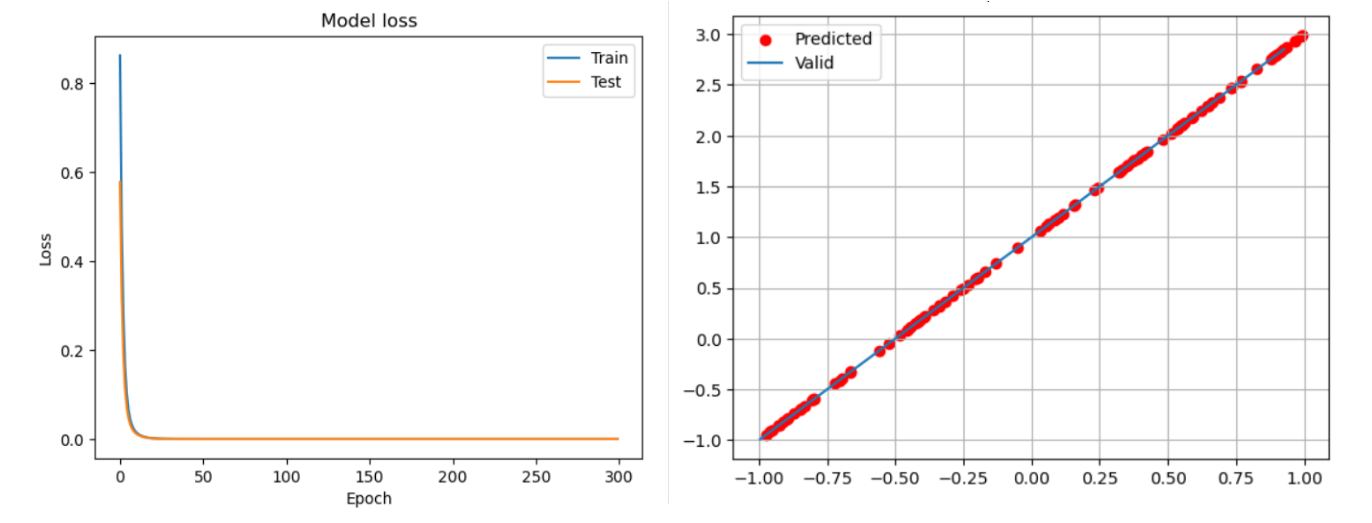

Se invece si aumenta il rumore a $\sigma = 0{,}5$, la precisione diminuisce:

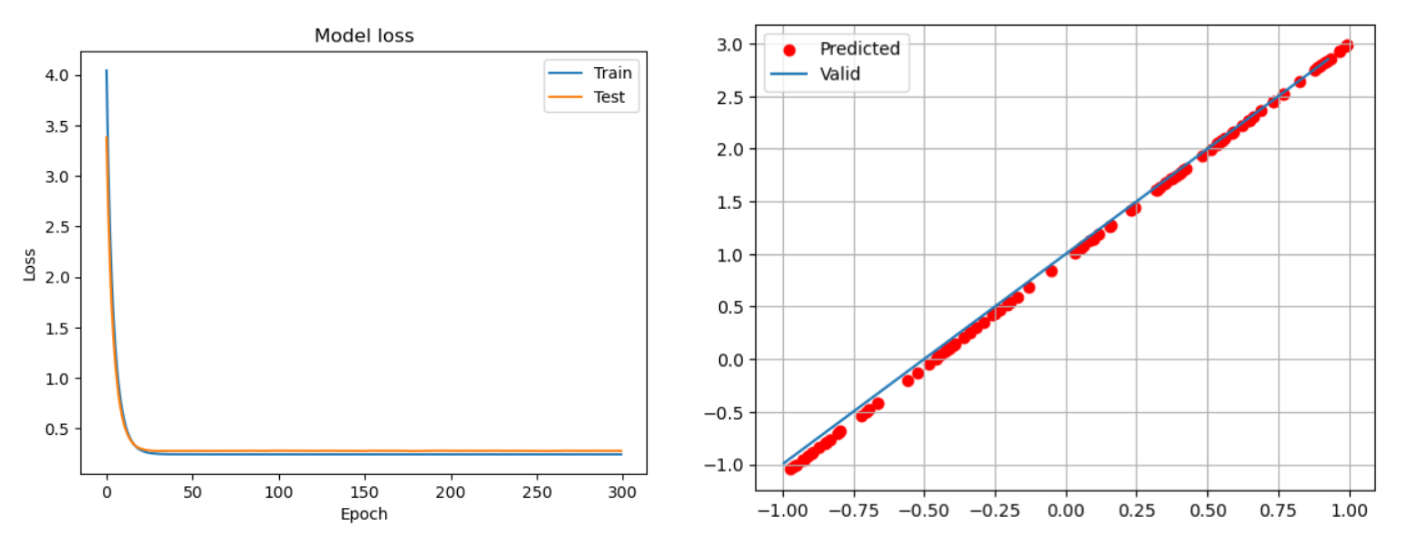

e diminuisce anche nel caso $epochs = 100$ e $N_{train} = 200$ (pur rimanendo un fit accettabile, con meno rumore e quindi meno necessità di dati e iterazioni), con però un tempo computazionale molto inferiore:

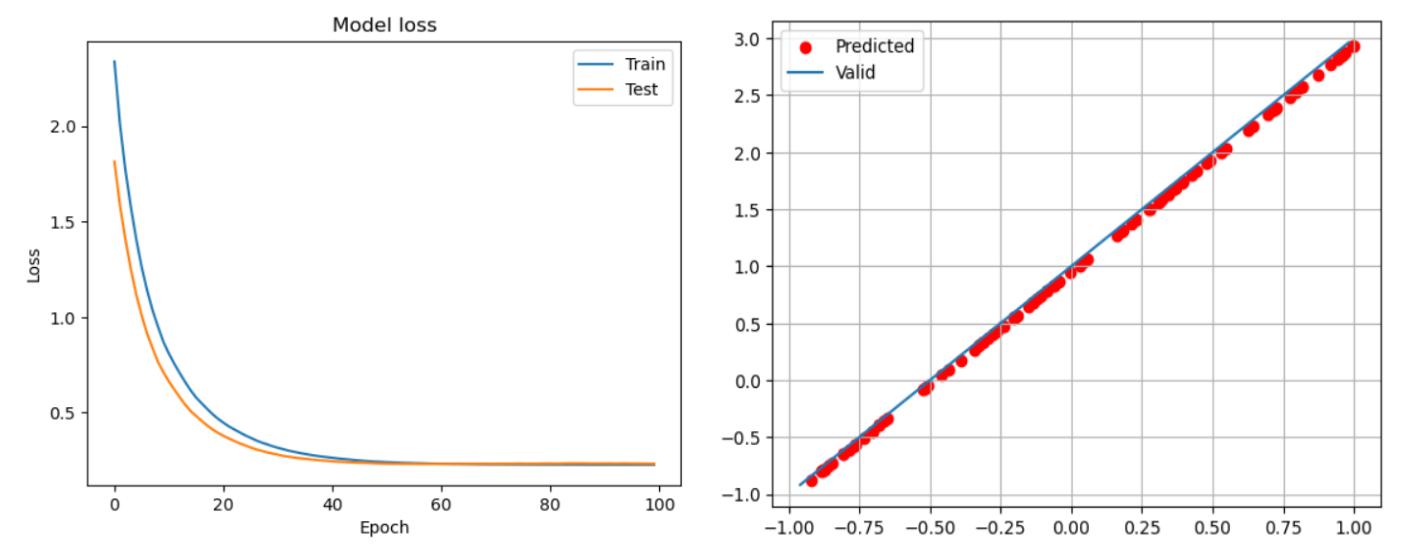

Pertanto, in presenza di rumore il valore della loss function non può mai raggiungere esattamente zero, poiché il modello non può prevedere completamente la componente aleatoria. Questo implica che valori più bassi di $epochs$ e $N_{train}$ possono comunque risultare sufficienti per la rete neurale.

In [ ]:
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True' #This is needed in my Anaconda+MacOsX installation; leave it commented.

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

import math
import numpy as np
import matplotlib.pyplot as plt

# target parameters of f(x) = m*x + b
m = 2           # slope
b = 1           # intersect
sigma = 0.5     # noise
N_train = 200   # number of data points

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

# compose the NN model
model = tf.keras.Sequential()
model.add(Dense(1, input_shape=(1,)))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

# get a summary of our composed model
model.summary()

# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=100, verbose=0,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))
print("Fitting finished")
# return weights and biases
weights = model.get_weights()

# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r', label='Predicted')
plt.plot(x_valid, y_target, label='Valid')
plt.legend()
plt.grid(True)
plt.show()

### Exercise 11.2
Nella seconda parte dell’esercizio si estende il modello alla funzione:
$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Si ricercano quindi i migliori iperparametri: si aumenta leggermente il numero di layer e di neuroni per layer (dato che la funzione resta semplice, anche una struttura più piccola sarebbe stata sufficiente), si cambia la funzione di attivazione da lineare a *ReLU*, scelta standard per reti neurali con input e hidden layers. La loss function rimane l’*MSE*, tipica dei problemi di regressione, mentre l’ottimizzatore viene sostituito con *Adam*, che permette un learning rate adattivo ed evita alcuni problemi tipici di metodi come *Adagrad* o *Adadelta* (in alternativa si sarebbe potuto provare *SGD* in caso di scarse prestazioni).

Con $\sigma = 0{,}5$, $epochs = 40$ e $N_{train} = 600$ si ottiene:

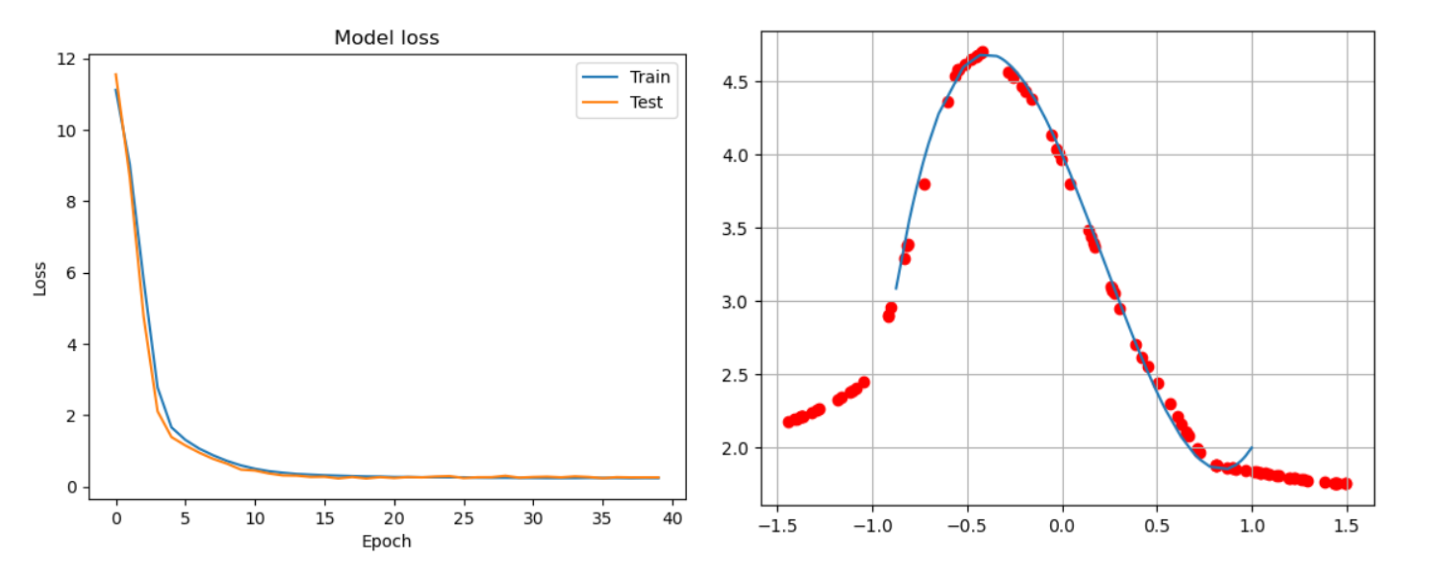

È stata inoltre verificata la capacità del modello di predire valori al di fuori dell’intervallo di training: il modello non riesce a generalizzare oltre il range addestrato. Questo dimostra che l’apprendimento della rete è limitato alla distribuzione dei dati di training e non può estrapolare la legge fisica/funzionale al di fuori di essa.

In [ ]:
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True' #This is needed in my Anaconda+MacOsX installation; leave it commented.

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

import math
import numpy as np
import matplotlib.pyplot as plt

def f(x):       # f(x) = 4 - 3x - 2x^2 +3x^3
    return 4-3*x-2*x**2+3*x**3
    
sigma = 0.5     # noise
N_train = 600   # number of data points

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = f(x_valid)

y_train = np.random.normal(f(x_train), sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(f(x_valid), sigma)

# compose the NN model
model = tf.keras.Sequential()
model.add(Dense(40, input_shape=(1,), activation='relu'))
model.add(Dense(25, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

# get a summary of our composed model
model.summary()

# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=40, verbose=0,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))
print("Fitting finished")
# return weights and biases
weights = model.get_weights()

# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

x_predicted = np.random.uniform(-1.5, 1.5, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()

### Exercise 11.3
Nell’ultima parte si considera la funzione bidimensionale:
$$
f(x,y) = \sin(x^2+y^2)$$ 

con dominio $x \in [-3/2,3/2]$ e $y \in [-3/2,3/2]$.
Si tratta di una funzione in $2D$, quindi è necessario introdurre due variabili di input e combinarle in una struttura matriciale per il training della rete. Mantenendo la stessa loss function e lo stesso ottimizzatore dell’esercizio $11.2$, si modifica la funzione di attivazione in tanh, più adatta a funzioni periodiche/trigonometriche. Inoltre si riduce il rumore a $\sigma = 0{,}2$, poiché la funzione varia tra $-1$ e $1$ e un rumore troppo elevato introdurrebbe distorsioni significative. Si impostano infine $epochs = 250$ e $N_{train} = 3000$, necessari dato l’aumento della complessità del problema (due variabili e funzione più strutturata).

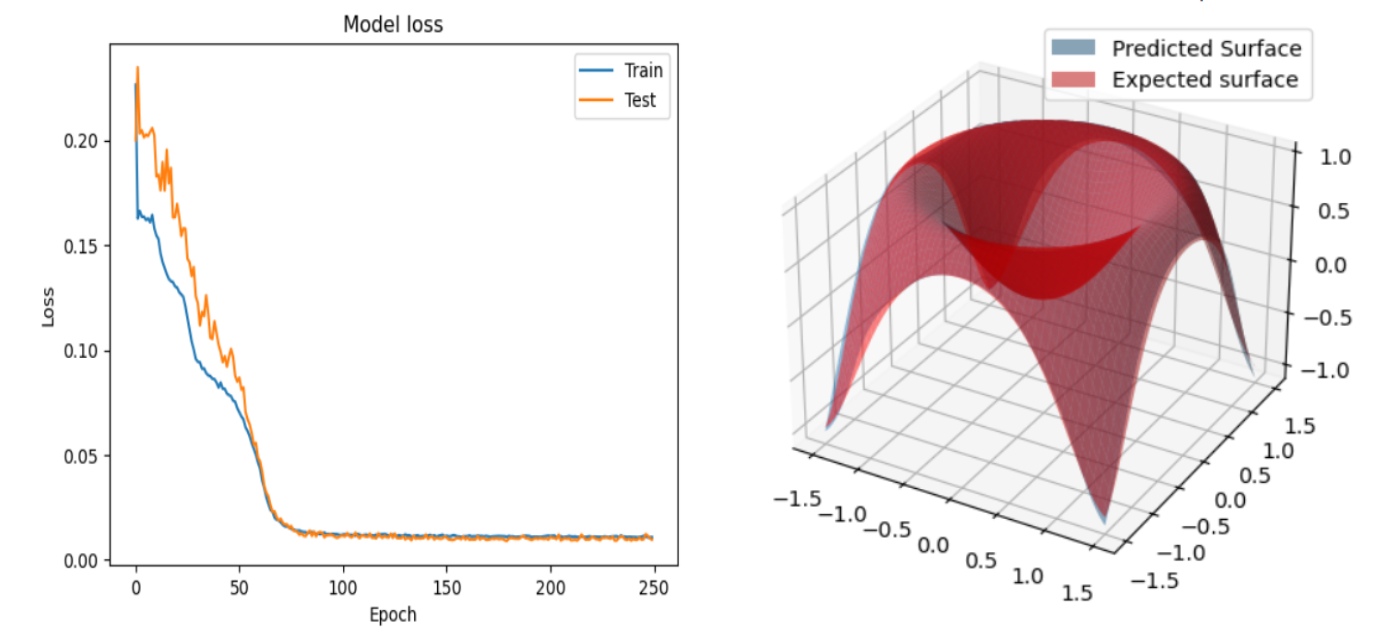


In [ ]:
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True' #This is needed in my Anaconda+MacOsX installation; leave it commented.

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

import math
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):       # f(x) = sin(x^2 + y^2)
    return np.sin(x**2 + y**2)
    
sigma = 0.1     # noise
N_train = 3000   # number of data points

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1.5, 1.5, N_train)
y_train = np.random.uniform(-1.5, 1.5, N_train)
X_train = np.column_stack([x_train, y_train])
x_valid = np.random.uniform(-1.5, 1.5, 100)
y_valid = np.random.uniform(-1.5, 1.5, 100)
X_valid = np.column_stack([x_valid, y_valid])

z_train = np.random.normal(f(x_train, y_train), sigma) # actual measures from which we want to guess regression parameters
z_valid = np.random.normal(f(x_valid, y_valid), sigma)

# compose the NN model
model = tf.keras.Sequential()
model.add(Dense(60, input_shape=(2,), activation='tanh'))
model.add(Dense(60, activation='tanh'))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

# get a summary of our composed model
model.summary()

# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=X_train, y=z_train, 
          batch_size=32, epochs=250, verbose=0,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(X_valid, z_valid))
print("Fitting finished")
# return weights and biases
weights = model.get_weights()

# evaluate model
score = model.evaluate(X_valid, z_valid, batch_size=32, verbose=1)

# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

x_mesh = np.linspace(-1.5, 1.5, 100)
y_mesh = np.linspace(-1.5, 1.5, 100)
x_mesh, y_mesh = np.meshgrid(x_mesh, y_mesh)
z_target = f(x_mesh, y_mesh)

X_predict = np.column_stack([x_mesh.ravel(), y_mesh.ravel()])
z_predicted = model.predict(X_predict)
z_predicted = z_predicted.reshape(x_mesh.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_mesh, y_mesh, z_predicted, alpha=0.5, label='Predicted Surface')
ax.plot_surface(x_mesh, y_mesh, z_target, alpha=0.5, color='red', label='Expected surface')
plt.legend()
plt.grid(True)
plt.show()